
# Day 29 — Clustering Basics + KMeans

---

# 🚀 What You Will Learn

✅ Clustering Basics  
✅ KMeans Clustering  
✅ Centroid  
✅ WCSS  
✅ Elbow Method  
✅ Silhouette Score  
✅ Practical Use Cases  
✅ Advantages & Limitations  

---



# 1️⃣ What is Clustering?

Clustering is an **Unsupervised Machine Learning** technique.

The goal is to group similar data points together without using labels.

---

# Simple Intuition

Imagine a shopping mall dataset:

| Customer | Income | Spending |
|---|---|---|
| A | High | High |
| B | Low | Low |
| C | Medium | High |

Clustering automatically discovers hidden groups such as:

- Premium Customers
- Budget Customers
- Occasional Buyers

---

# Why Clustering Matters

Clustering is heavily used in:

- BFSI Customer Segmentation
- Fraud Pattern Discovery
- Recommendation Systems
- Healthcare Patient Grouping
- Telecom Churn Analysis

---



# 2️⃣ Distance in Clustering

Clustering depends heavily on distance calculation.

---

# Euclidean Distance

Most common distance metric:

$$
d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}
$$

This measures straight-line distance.

---

# Why Distance Matters

The closer the points:

➡ More likely they belong to same cluster.

The farther the points:

➡ More likely they belong to different clusters.

---



# 3️⃣ KMeans Clustering

KMeans is a **Partition-Based Clustering Algorithm**.

It divides data into **K clusters**.

Each cluster has a center called a:

# 🎯 Centroid

---

# Main Goal

Group similar points around centroids.

---

# Example

If K = 3:

The algorithm creates:

- Cluster 1
- Cluster 2
- Cluster 3

Each cluster gets its own centroid.

---



# 4️⃣ What is a Centroid?

Centroid is the average location of all points in a cluster.

---

# Formula

$$
Centroid = \frac{1}{N}\sum_{i=1}^{N}x_i
$$

---

# Simple Intuition

Imagine finding the “center of gravity” of all points.

The centroid continuously moves during training until it becomes stable.

---



# 5️⃣ Step-by-Step Working of KMeans

---

## Step 1: Choose K

Example:

K = 3

---

## Step 2: Initialize Random Centroids

The algorithm randomly picks cluster centers.

---

## Step 3: Assign Points

Every point joins the nearest centroid.

---

## Step 4: Update Centroids

Centroids become the average of assigned points.

---

## Step 5: Repeat

Repeat until centroids stop changing.

---



# 6️⃣ WCSS (Within Cluster Sum of Squares)

KMeans tries to minimize:

# 🎯 WCSS

---

# Formula

$$
WCSS = \sum_{i=1}^{K}\sum_{x_j \in C_i}||x_j-\mu_i||^2
$$

---

# Meaning

WCSS measures:

➡ How compact the clusters are.

Lower WCSS:

✅ Better clustering  
✅ Tighter clusters  

Higher WCSS:

❌ Poor clustering  
❌ Scattered clusters  

---



# 7️⃣ Elbow Method

One major problem in KMeans:

# ❓ How to choose K?

The Elbow Method helps solve this.

---

# Idea

Train KMeans for multiple K values.

Example:

K = 1 to 10

Calculate WCSS for each K.

---

# Observation

As K increases:

- WCSS decreases
- Clusters become tighter

But after some point:

Improvement slows down.

That point forms an:

# 🎯 Elbow

The elbow point is usually the optimal K.

---


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

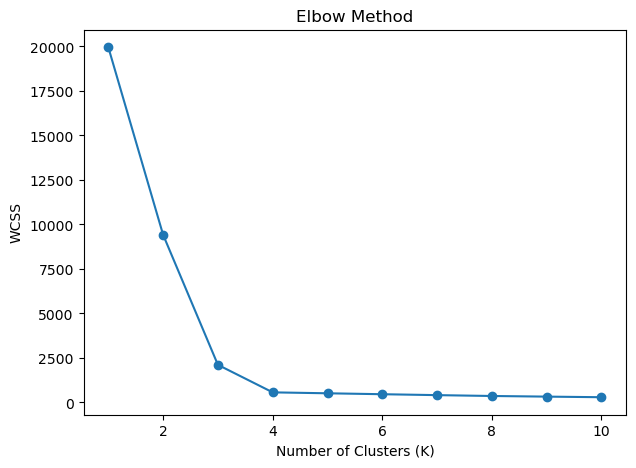

In [1]:

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    wcss.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()



# 8️⃣ Silhouette Score

Silhouette Score measures cluster quality.

---

# Range

| Score | Meaning |
|---|---|
| Near +1 | Excellent Clustering |
| Near 0 | Overlapping Clusters |
| Near -1 | Incorrect Clustering |

---

# Why Important?

Elbow Method is visual.

Silhouette Score gives a numerical evaluation.

---


In [2]:

from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)

print("Silhouette Score:", round(score, 3))


Silhouette Score: 0.792


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



# 9️⃣ Visualizing Clusters

Visualization helps understand:

- Cluster boundaries
- Centroid positions
- Separation quality

---


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


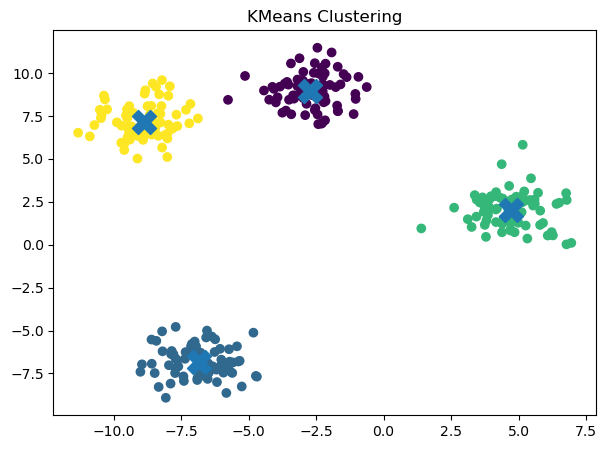

In [3]:

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

labels = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_

plt.figure(figsize=(7,5))

plt.scatter(X[:,0], X[:,1], c=labels)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=300,
    marker='X'
)

plt.title("KMeans Clustering")
plt.show()



# 🔟 Practical Business Use Cases

| Industry | Use Case |
|---|---|
| Banking | Customer Segmentation |
| E-commerce | Product Recommendation |
| Telecom | Churn Pattern Detection |
| Healthcare | Patient Grouping |
| Cybersecurity | Threat Pattern Detection |

---

# BFSI Example

A bank can cluster customers based on:

- Salary
- Spending
- Loan Usage
- Credit Behavior

This helps create:

✅ Personalized Offers  
✅ Risk-Based Marketing  
✅ Premium Customer Programs  

---



# 1️⃣1️⃣ Advantages of KMeans

✅ Simple to Understand

✅ Fast & Scalable

✅ Works Well on Large Datasets

✅ Easy to Implement

✅ Effective for Customer Segmentation

---



# 1️⃣2️⃣ Limitations of KMeans

❌ Must Choose K Manually

❌ Sensitive to Outliers

❌ Assumes Spherical Clusters

❌ Poor Performance on Irregular Shapes

❌ Different Initialization Can Change Results

---



# 1️⃣3️⃣ Important Interview Questions

## Q1: Why is feature scaling important in clustering?

Because clustering uses distance calculations.

Large-value features dominate the model.

---

## Q2: What is inertia?

Inertia = WCSS

Lower inertia means tighter clusters.

---

## Q3: Why is KMeans sensitive to outliers?

Outliers shift centroids heavily.

---

## Q4: Why use Elbow Method?

To determine optimal K.

---



# 1️⃣4️⃣ Key Takeaways

✅ Clustering is unsupervised learning

✅ KMeans groups similar points

✅ Centroids represent cluster centers

✅ WCSS measures compactness

✅ Elbow Method helps choose K

✅ Silhouette Score evaluates quality

✅ KMeans is heavily used in BFSI and recommendation systems

---
